In [1]:
import matplotlib as pl
import pandas as pd
import sklearn as sc
import seaborn as sns


## Teil 2

#### a)

In [2]:
samples,labels,centers = sc.datasets.make_blobs(n_samples=1000, n_features=5, centers=4, cluster_std=3, random_state=0,return_centers=True)

#### b)

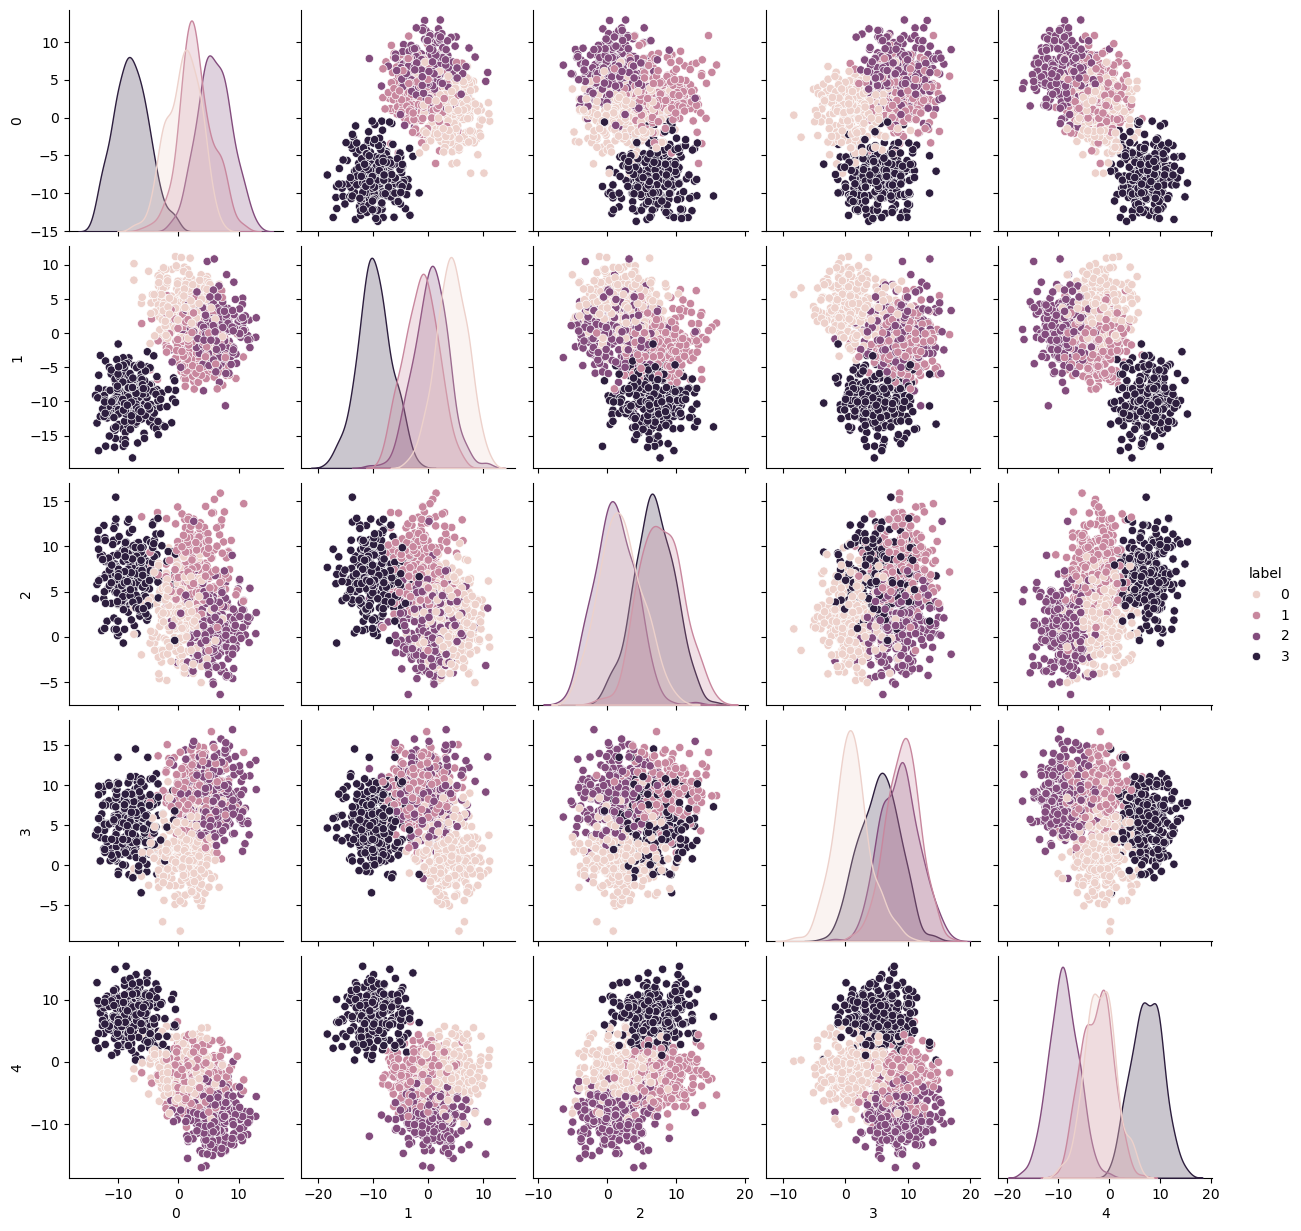

In [3]:
df = pd.DataFrame(samples, columns=[f'{i}' for i in range((centers.shape[1]))])
df["label"]=labels

sns.pairplot(df, hue="label")

#### c)

In [4]:
kmeans = sc.cluster.KMeans(n_clusters=4, random_state=1).fit(samples)
kmeans_predict = kmeans.predict(samples)

#### d)

In [5]:
kmeans_score = sc.metrics.silhouette_score(X=df, labels=kmeans_predict, random_state=1)
print(kmeans_score)
# Wir haben uns für silhoutte_score als metrik entschieden da hier mit angegeben wird wie zuverlässig ein wert dem richtigen cluster zugeordnet wird,wo bei 1 eine klare clusterzuordnung ist und -1 einer falschen cluster zuordnung entspricht.
# entsprechend der metrik zeigt sich hier zwar eine zuordnung, die aber eher vage als zuverlässig ist.

0.37572665268214334


#### e)

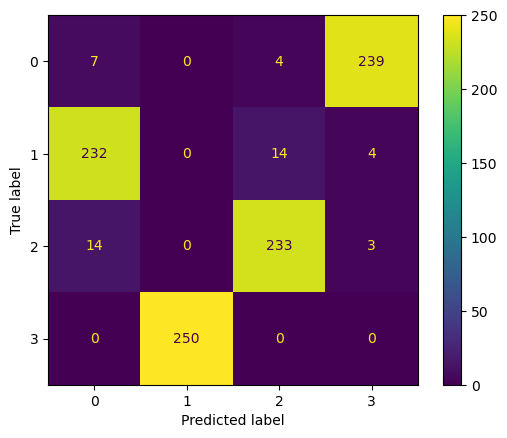

In [6]:
confusion_matrix = sc.metrics.confusion_matrix(y_true=labels, y_pred=kmeans_predict)
disp = sc.metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
disp.plot()
# wie in der Metrik schon zu erahnen war, wird eine Klassifizierung sehr zuverlässig durch geführt der rest ist aber fehlerhaft, eine Konfusionsmatrix ist insofern ein geeignetes werkzeug da hier gut zu erkennen ist in welchem verhältnis und bei welchem Clustern eine korrekte und eine fehlerhafte Klassifikation erfolgt ist.

#### f)

In [7]:
X_train, X_test, y_train, y_test = sc.model_selection.train_test_split(samples, labels, train_size=0.8, random_state=1)

#### g)

In [8]:
clf = sc.tree.DecisionTreeClassifier(criterion="gini", min_impurity_decrease=0.05)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

#### h)

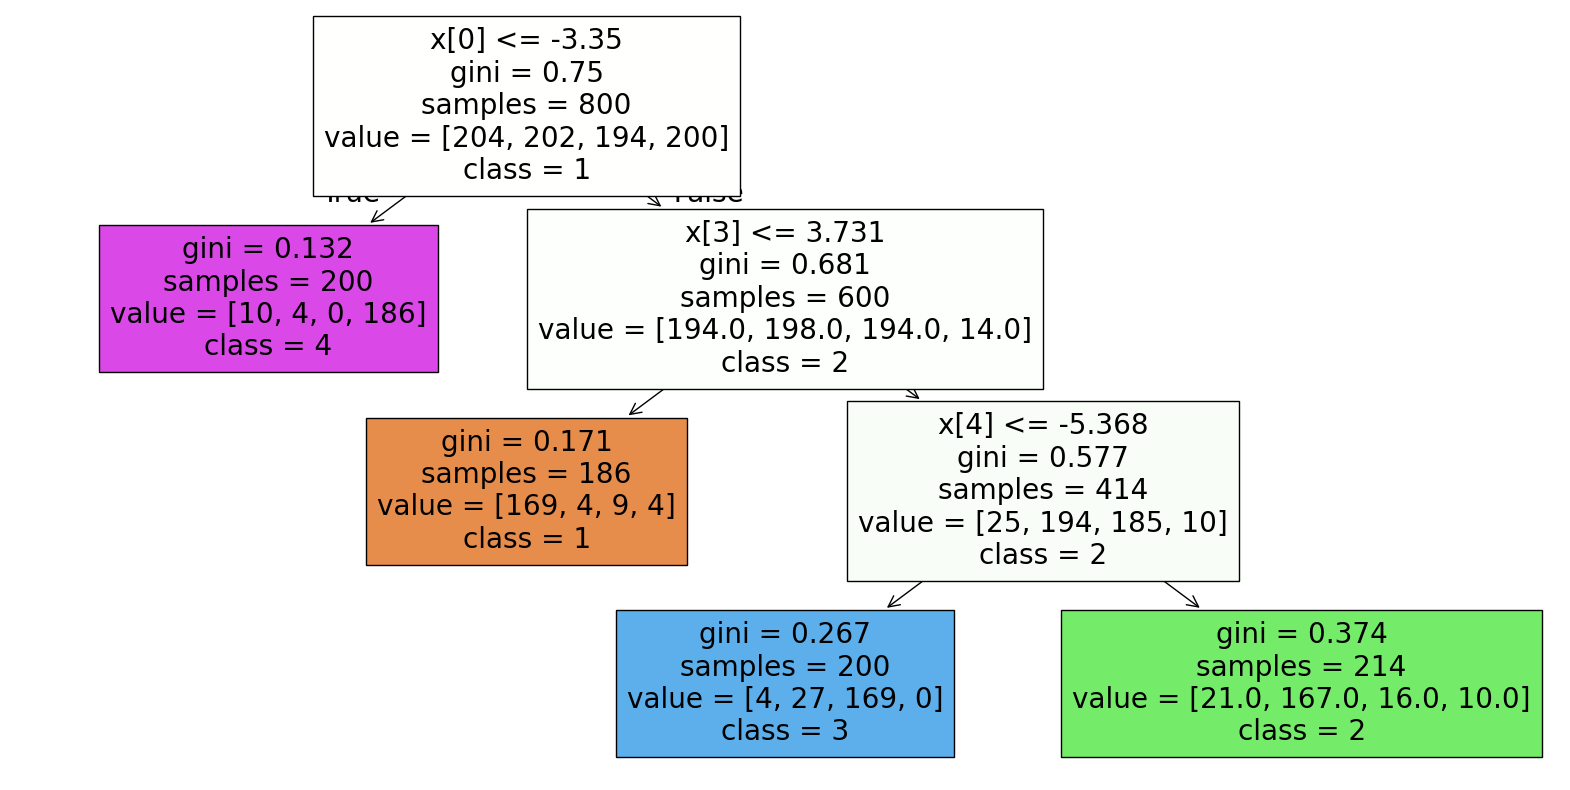

In [9]:
pl.pyplot.figure(figsize=(20, 10))
sc.tree.plot_tree(clf, filled=True,class_names=['1','2','3','4'])
pl.pyplot.show()

#### i)

<Axes: >

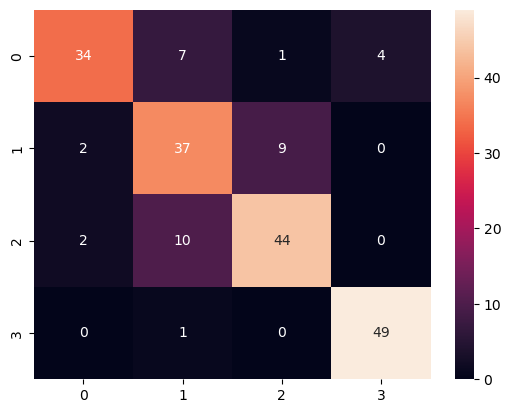

In [10]:
clf_predict = clf.predict(X_test)
confusion_matrix_clf = sc.metrics.confusion_matrix(y_true=y_test, y_pred=clf_predict)
confusion_matrix_df = pd.DataFrame(confusion_matrix_clf)
sns.heatmap(confusion_matrix_df, annot=True)

#### j)

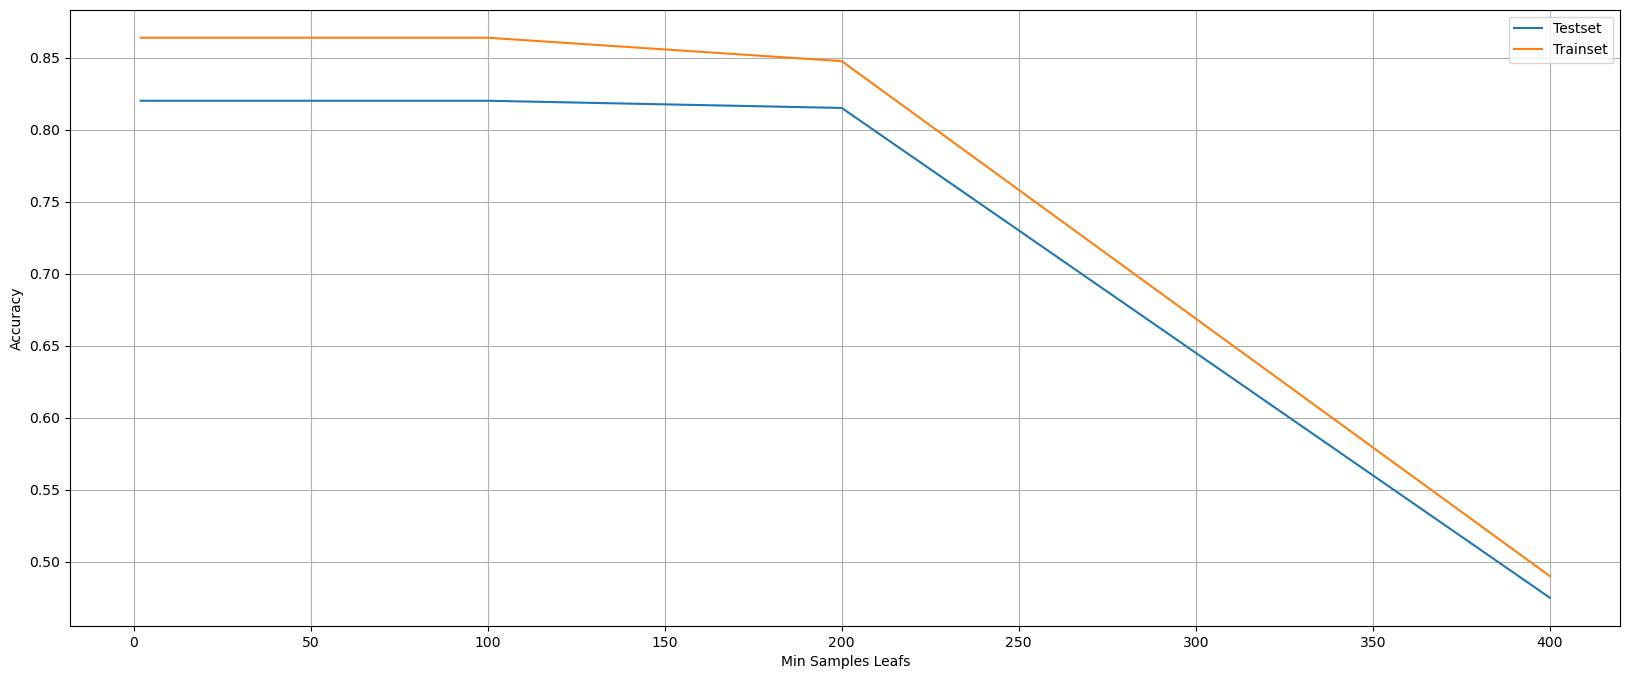

In [11]:
min_samples_leaf = [400, 200, 100, 50, 25, 12, 6, 2]

accuracy_train = []
accuracy_test = []

for i in min_samples_leaf:
    clf_tree = sc.tree.DecisionTreeClassifier(criterion="gini", min_impurity_decrease=0.05, min_samples_leaf=i)
    clf_tree.fit(X_train, y_train)
    clf_tree_predict_test = clf_tree.predict(X_test)
    clf_tree_predict_train = clf_tree.predict(X_train)

    accuracy_train.append(sc.metrics.accuracy_score(y_true=y_train, y_pred=clf_tree_predict_train))
    accuracy_test.append(sc.metrics.accuracy_score(y_true=y_test, y_pred=clf_tree_predict_test))

pl.pyplot.figure(figsize=(20, 8))
pl.pyplot.grid(True)
pl.pyplot.plot(min_samples_leaf, accuracy_test, label="Testset")
pl.pyplot.plot(min_samples_leaf, accuracy_train, label="Trainset")
pl.pyplot.xlabel("Min Samples Leafs")
pl.pyplot.ylabel("Accuracy")
pl.pyplot.legend(loc='best')
pl.pyplot.show()


#### k)

In [12]:
rfc = sc.ensemble.RandomForestClassifier(n_estimators=20,random_state=1)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

#### i)

Genauigkeit Random-Forest-Klassifikator: 0.94


Text(0.5, 1.0, 'Random-Forest-Klassifikator')

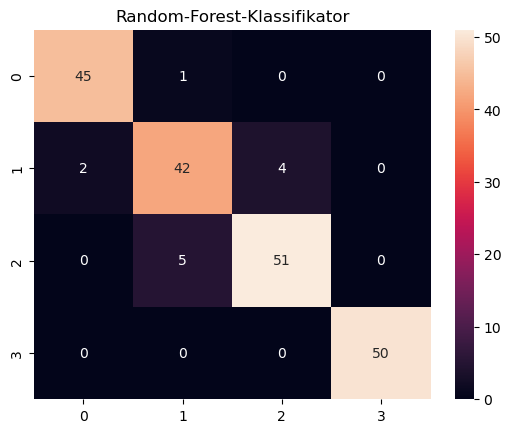

In [13]:
rfc_predict = rfc.predict(X_test)
accuracy_rfc = sc.metrics.accuracy_score(y_true=y_test, y_pred=rfc_predict)
print(f"Genauigkeit Random-Forest-Klassifikator: {accuracy_rfc}")
confusion_matrix_rfc = sc.metrics.confusion_matrix(y_true=y_test, y_pred=rfc_predict)
ax = pl.pyplot.axes()
sns.heatmap(confusion_matrix_rfc, annot=True,ax=ax)
ax.set_title("Random-Forest-Klassifikator")

Genauigkeit Decision-Tree-Klassifikator: 0.82


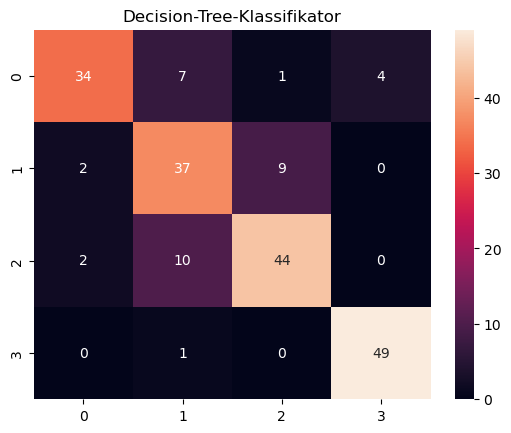

In [14]:
ax = pl.pyplot.axes()
sns.heatmap(confusion_matrix_df, annot=True,ax=ax)
ax.set_title("Decision-Tree-Klassifikator")
accuracy_clf = sc.metrics.accuracy_score(y_true=y_test, y_pred=clf_predict)
print(f"Genauigkeit Decision-Tree-Klassifikator: {accuracy_clf}")

Genauigkeit kmeans Klassifikator: 0.24


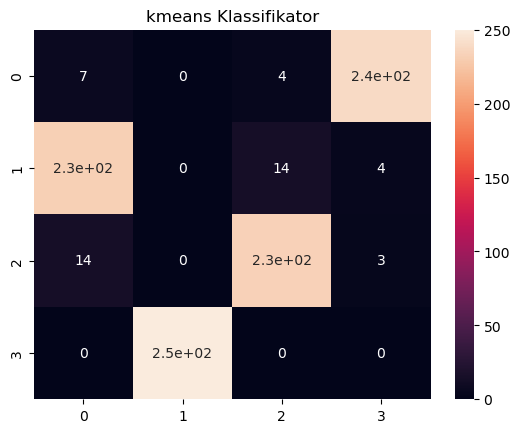

In [15]:
ax = pl.pyplot.axes()
sns.heatmap(confusion_matrix, annot=True,ax=ax)
ax.set_title("kmeans Klassifikator")
accuracy_kmeans = sc.metrics.accuracy_score(y_true=df["label"], y_pred=kmeans_predict)
print(f"Genauigkeit kmeans Klassifikator: {accuracy_kmeans}")

#### m)
##### bericht rfc

In [16]:
report = sc.metrics.classification_report(y_true=y_test,y_pred=rfc_predict)
print(report)
#precision: anteil true positiv zu predicted positiv (tp/(tp+fp) -> zuverlässigkeit der positiven Vorhersagen
#recall: korrekt erkannte positive im verhältnis gesamt Positive (tp/(tp+fn) -> Trefferquote der positiven Fälle
#f1-Score: bezieht Precision und recall zu einem Kenzahl zusammen ((2*pre*rec)/(pre+rec))
#support: Anzahl der Klasse im Datensatz

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        46
           1       0.88      0.88      0.88        48
           2       0.93      0.91      0.92        56
           3       1.00      1.00      1.00        50

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

